In [117]:
from src.api.option_fetcher import OptionFetcher
from src.analysis.volatility_smile import VolatilitySmileAnalyzer
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
import importlib
import src.api.option_fetcher as option_fetcher
import src.analysis.volatility_smile as volatility_smile

importlib.reload(option_fetcher)
OptionFetcher = option_fetcher.OptionFetcher

importlib.reload(volatility_smile)
VolatilitySmileAnalyzer = volatility_smile.VolatilitySmileAnalyzer

In [119]:
load_dotenv()
api_key = os.getenv("API_KEY")
secret_key = os.getenv("SECRET_KEY")

In [120]:
ticker = "SPY"
expiration_dates = [
    "2026-05-22",
    "2026-05-29",
    "2026-06-05",
    "2026-06-12",
    "2026-06-19",
    "2026-06-26",
    "2026-07-03",
    "2026-07-10",
    "2026-07-17",
    "2026-07-24",
    "2026-07-31",
    "2026-08-21",  # ~3 mois
    "2026-09-18",  # ~4 mois
    "2026-10-16",  # ~5 mois
    "2026-12-18",  # ~7 mois
    "2027-03-19",  # ~10 mois
    "2027-06-18",  # ~13 mois
    "2027-12-17",  # ~19 mois
]
spot_delta = 20

In [121]:
fetcher = OptionFetcher(api_key, secret_key)

In [122]:
spot_price = fetcher.get_spot_price(ticker)
df = fetcher.build_options_df(ticker,expiration_dates,spot_delta,100)
df

,symbol,strike,expiry,type,bid,ask,mid,spread,timestamp
0,SPY260522C00719000,719.0,2026-05-22,call,21.95,22.25,22.100,0.30,2026-05-15 19:59:59.617408+00:00
1,SPY260522C00720000,720.0,2026-05-22,call,20.81,21.15,20.980,0.34,2026-05-15 19:59:59.211199+00:00
2,SPY260522C00721000,721.0,2026-05-22,call,20.09,20.77,20.430,0.68,2026-05-15 19:59:59.650802+00:00
3,SPY260522C00722000,722.0,2026-05-22,call,19.22,19.86,19.540,0.64,2026-05-15 19:59:59.910392+00:00
4,SPY260522C00723000,723.0,2026-05-22,call,18.25,18.58,18.415,0.33,2026-05-15 19:59:59.704951+00:00
...,...,...,...,...,...,...,...,...,...
583,SPY271217P00735000,735.0,2027-12-17,put,56.04,56.30,56.170,0.26,2026-05-15 19:59:59.857114+00:00
584,SPY271217P00740000,740.0,2027-12-17,put,57.77,57.92,57.845,0.15,2026-05-15 19:59:59.331382+00:00
585,SPY271217P00745000,745.0,2027-12-17,put,57.79,57.94,57.865,0.15,2026-05-15 19:59:59.713446+00:00
586,SPY271217P00750000,750.0,2027-12-17,put,60.11,60.41,60.260,0.30,2026-05-15 19:59:59.878430+00:00


In [123]:
smile = VolatilitySmileAnalyzer(df, spot_price, 0.045)
smile_df = smile.build_smile_data()

In [124]:
smile_df

,implied_vol,strike,expiration_date,time_to_expiry,moneyness,type
0,0.214793,719.0,2026-05-22,0.018452,0.973529,call
1,0.203046,720.0,2026-05-22,0.018452,0.974883,call
2,0.213067,721.0,2026-05-22,0.018452,0.976237,call
3,0.209659,722.0,2026-05-22,0.018452,0.977591,call
4,0.197784,723.0,2026-05-22,0.018452,0.978945,call
...,...,...,...,...,...,...
583,0.225590,735.0,2027-12-17,1.589978,0.995193,put
584,0.224312,740.0,2027-12-17,1.589978,1.001963,put
585,0.218169,745.0,2027-12-17,1.589978,1.008733,put
586,0.218779,750.0,2027-12-17,1.589978,1.015503,put


In [136]:
expiry_date = "2026-05-22"
target = pd.to_datetime(expiry_date).date()
smile_data_2d = smile_df[(smile_df["expiration_date"] == target)]

In [137]:
smile_data_2d

,implied_vol,strike,expiration_date,time_to_expiry,moneyness,type
0,0.214793,719.0,2026-05-22,0.018452,0.973529,call
1,0.203046,720.0,2026-05-22,0.018452,0.974883,call
2,0.213067,721.0,2026-05-22,0.018452,0.976237,call
3,0.209659,722.0,2026-05-22,0.018452,0.977591,call
4,0.197784,723.0,2026-05-22,0.018452,0.978945,call
...,...,...,...,...,...,...
75,0.130762,754.0,2026-05-22,0.018452,1.020919,put
76,0.123282,755.0,2026-05-22,0.018452,1.022273,put
77,0.114474,756.0,2026-05-22,0.018452,1.023627,put
78,0.109211,757.0,2026-05-22,0.018452,1.024981,put


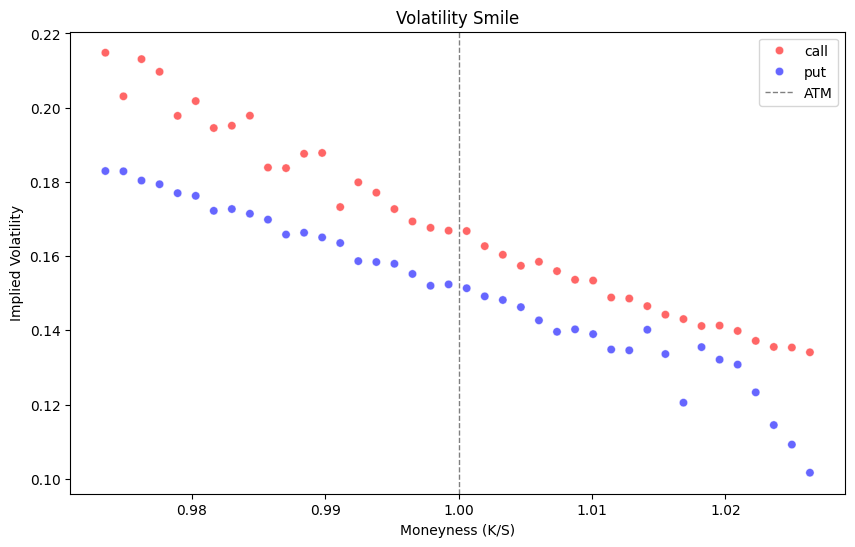

In [138]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smile_data_2d, x='moneyness', y='implied_vol', hue='type', 
                palette={'put': 'blue', 'call': 'red'}, alpha=0.6)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1, label='ATM')
plt.xlabel("Moneyness (K/S)")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.legend()
plt.show()

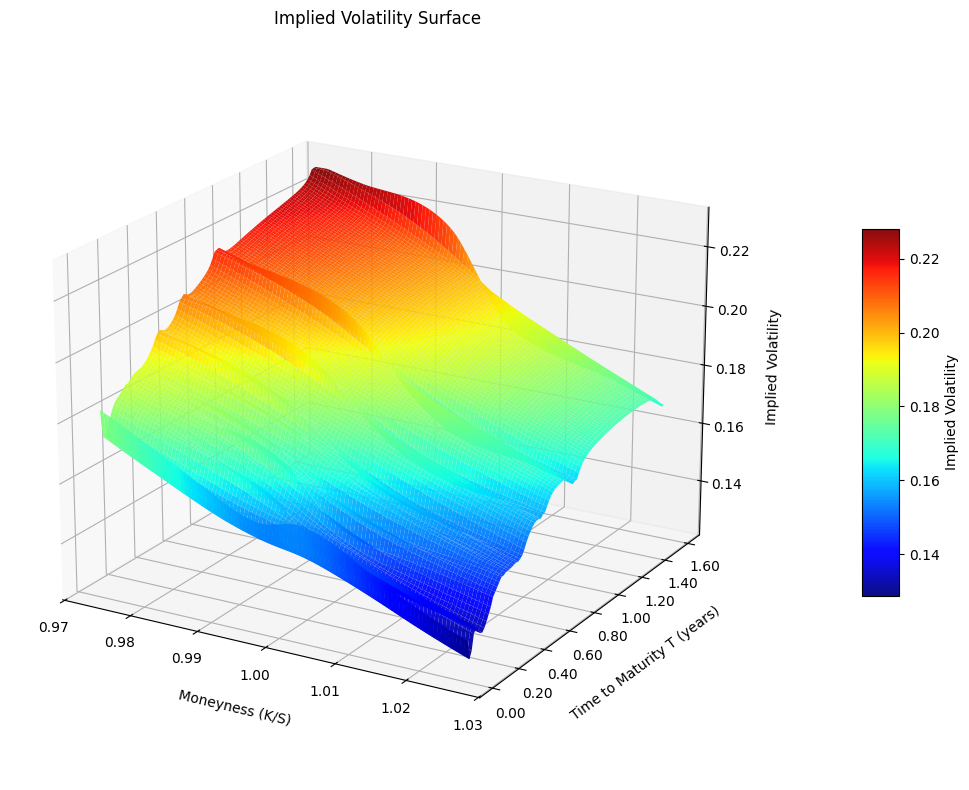

In [ ]:
import numpy as np
from scipy.interpolate import griddata, RBFInterpolator
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = smile_df.dropna(subset=['strike', 'implied_vol', 'time_to_expiry', 'moneyness', 'type']).copy()
df['time_to_expiry'] = df['time_to_expiry'].astype(float)

# Put-call parity splitting : puts pour K < S (moneyness < 1), calls pour K > S (moneyness > 1)
# ATM (moneyness == 1 exactement) : on garde les calls par défaut
spot_proxy = df['strike'].iloc[(df['moneyness'] - 1).abs().argsort().iloc[0]]  # strike le plus proche de ATM

df_surface = pd.concat([
    df[(df['type'] == 'put')  & (df['strike'] <  spot_proxy)],
    df[(df['type'] == 'call') & (df['strike'] >= spot_proxy)],
])

# Lissage Savitzky-Golay par maturité
df_surface = df_surface.sort_values(['time_to_expiry', 'moneyness'])
smoothed_vols = []
for mat, group in df_surface.groupby('time_to_expiry'):
    group = group.sort_values('moneyness')
    vols = group['implied_vol'].values
    window = min(11, len(vols) if len(vols) % 2 == 1 else len(vols) - 1)
    vols_smooth = savgol_filter(vols, window_length=window, polyorder=3) if window >= 5 else vols
    smoothed_vols.extend(vols_smooth)
df_surface['implied_vol_smooth'] = smoothed_vols

# RBFInterpolator sur moneyness x time_to_expiry
points = df_surface[['moneyness', 'time_to_expiry']].values
values = df_surface['implied_vol_smooth'].values

xi = np.linspace(df_surface['moneyness'].min(), df_surface['moneyness'].max(), 100)
yi = np.linspace(df_surface['time_to_expiry'].min(), df_surface['time_to_expiry'].max(), 100)
Xi, Yi = np.meshgrid(xi, yi)
grid_points = np.column_stack([Xi.ravel(), Yi.ravel()])

rbf = RBFInterpolator(points, values, kernel='thin_plate_spline', smoothing=1e-4)
Zi = rbf(grid_points).reshape(Xi.shape)

vol_min, vol_max = df_surface['implied_vol'].min(), df_surface['implied_vol'].max()
Zi = np.clip(Zi, vol_min, vol_max)

# --- Plot ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    Xi, Yi, Zi,
    cmap='jet',
    edgecolor='none',
    antialiased=True,
    rcount=150,
    ccount=150,
    alpha=0.95
)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Implied Volatility')

zp = 0.05 * (vol_max - vol_min)
ax.set_zlim(max(0.0, vol_min - zp), vol_max + zp)

ax.view_init(elev=20, azim=-60)
ax.set_xlabel('Moneyness (K/S)', labelpad=12)
ax.set_ylabel('Time to Maturity T (years)', labelpad=12)
ax.set_zlabel('Implied Volatility', labelpad=10)
ax.set_title('Implied Volatility Surface', pad=15)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()